This notebook should help answer the following questions:

1) How many observations are there?
2) What columns exist?
3) What is cnt?
4) Are there missing values?
5) What does the datetime look like?
6) Is the data chronologically ordered?
7) Are there timestamp gaps?
8) What does hourly demand look like?
9) What does weekly demand look like?
10) What does monthly/seasonal demand look like?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('C:\\Users\\User\\Desktop\\basisbench\\data\\raw\\hour.csv')

#### Understand the data ####

See the shape, details about the data and see if there are any missing values.

In [3]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
df.columns #* features

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [5]:
df.shape #*(n_observations, n_features)

(17379, 17)

In [6]:
df.isna() #* data frame with all missing values rows ----> no missing values

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
17375,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
17376,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
17377,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isna().sum() #* confirmation of no missing values

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

### Understand the Target ###

See different statistics that describe the target variable; These include
1) mean
2) counts
3) standard deviation
4) The quantiles

In [8]:
df['cnt'].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

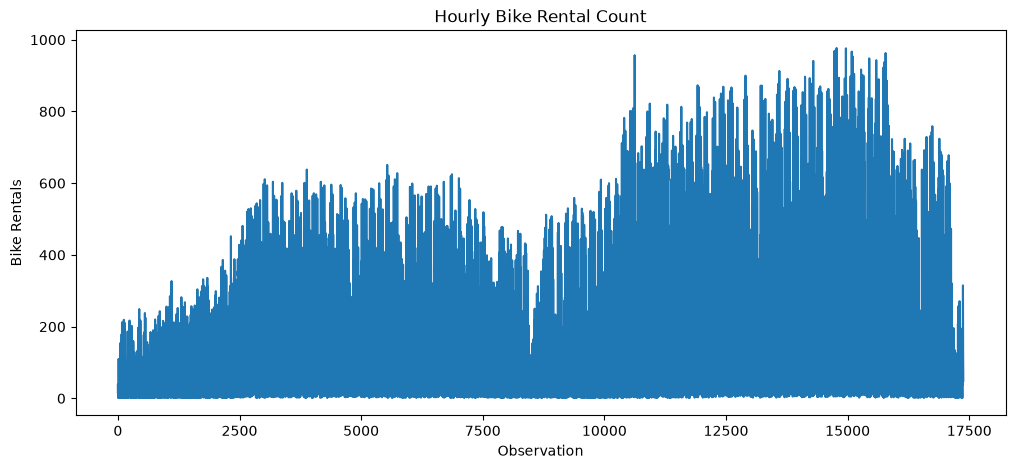

In [9]:
plt.figure(figsize=(12,5))

plt.plot(df['cnt'])
plt.xlabel('Observation')
plt.ylabel('Bike Rentals')
plt.title('Hourly Bike Rental Count')

plt.show()

### Understand the Input features ####

In [10]:
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [11]:
df['mnth'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [12]:
df['season'].unique(), df['yr'].unique()

(array([1, 2, 3, 4]), array([0, 1]))

### Get proper time stamps ####

In [13]:
df['datetime'] = (
    pd.to_datetime(df['dteday']) +
    pd.to_timedelta(df['hr'], unit ='h')
)

In [14]:
df[[ 'dteday','hr', 'datetime', 'cnt']].head()

,dteday,hr,datetime,cnt
0,2011-01-01,0,2011-01-01 00:00:00,16
1,2011-01-01,1,2011-01-01 01:00:00,40
2,2011-01-01,2,2011-01-01 02:00:00,32
3,2011-01-01,3,2011-01-01 03:00:00,13
4,2011-01-01,4,2011-01-01 04:00:00,1


In [15]:
df['datetime'].diff().value_counts().head()

datetime
0 days 01:00:00    17303
0 days 02:00:00       64
0 days 03:00:00        6
0 days 13:00:00        1
0 days 23:00:00        1
Name: count, dtype: int64

In [16]:
df['datetime'].is_monotonic_increasing

True

Look at the average rental count by hour

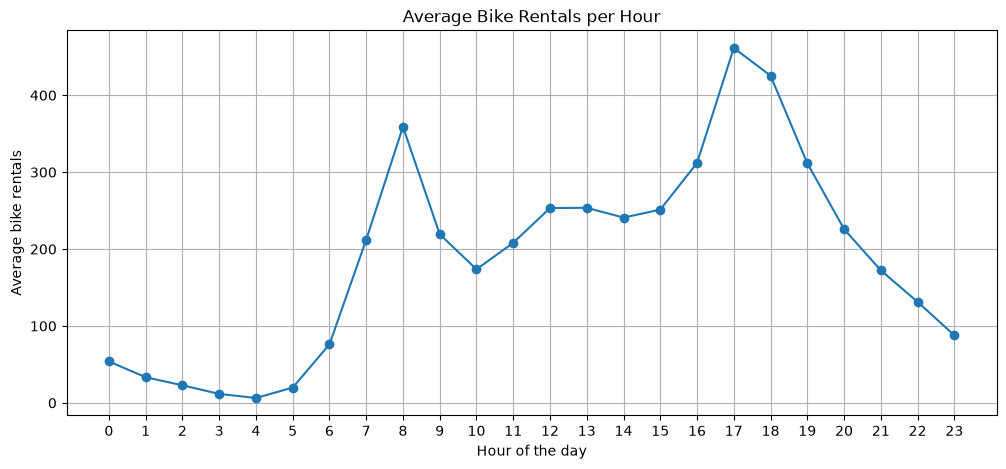

In [17]:
hourly_pattern = df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(12,5))
plt.plot(hourly_pattern, marker='o')

plt.xlabel('Hour of the day')
plt.ylabel('Average bike rentals')
plt.title('Average Bike Rentals per Hour')

plt.grid(visible=True)
plt.xticks(range(24))
plt.show()

The above plot shows that the average rental county by hour can be best represented by a sinosoidal approximation.

Look at the within-day structure.

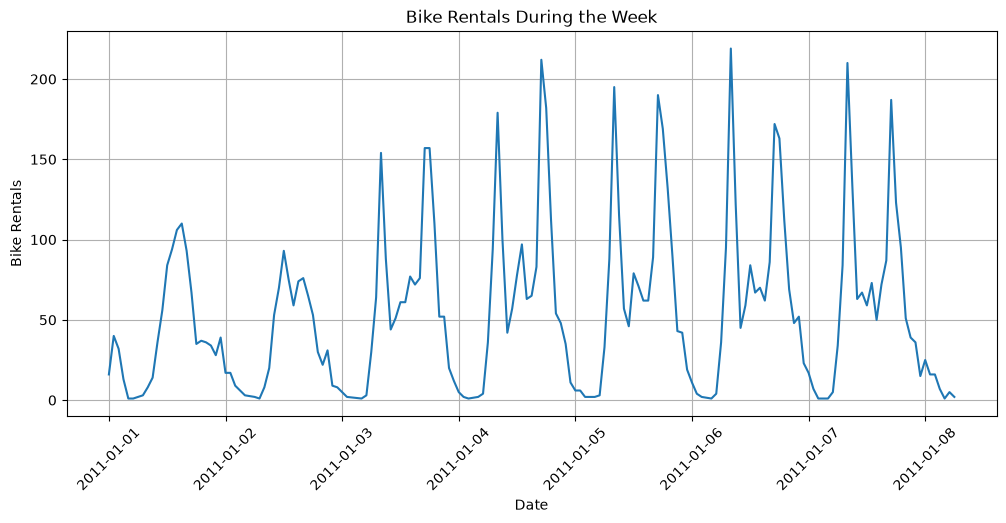

In [18]:
first_week = df.iloc[:24 * 7]

plt.figure(figsize=(12,5))
plt.plot(first_week['datetime'], first_week['cnt'])

plt.xlabel("Date")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals During the Week")

plt.grid(visible=True)
plt.xticks(rotation=45)
plt.show()

Look at the day of the week behavior

In [19]:
df.groupby(['workingday', 'hr'])['cnt'].mean()[0]

hr
0      90.800000
1      69.508696
2      53.171053
3      25.775330
4       8.264317
5       8.689189
6      18.742358
7      43.406926
8     105.653680
9     171.623377
10    255.909091
11    315.316017
12    366.259740
13    372.731602
14    364.645022
15    358.813853
16    352.727273
17    323.549784
18    281.056522
19    231.673913
20    174.739130
21    142.060870
22    116.060870
23     85.930435
Name: cnt, dtype: float64

weekly Demand: working day V non working day

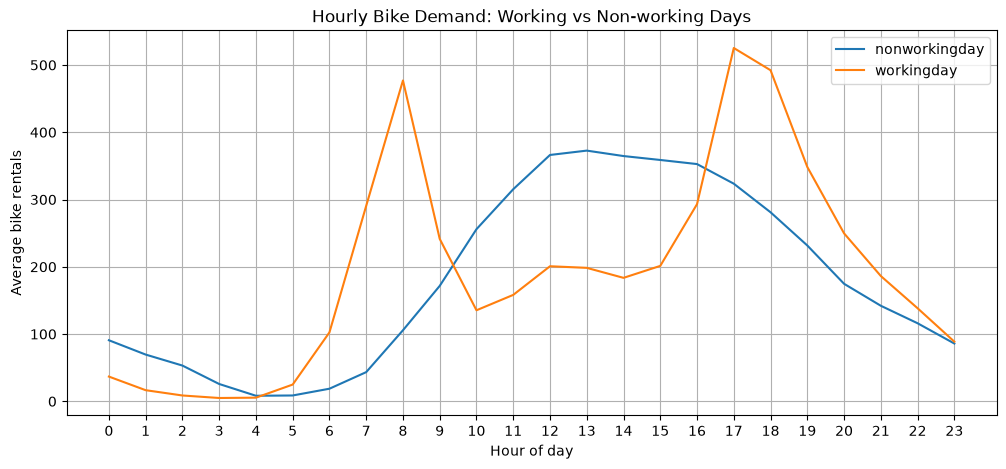

In [20]:
weekly_pattern = df.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

plt.figure(figsize=(12,5))

for day in [0,1]:
    subset = weekly_pattern[weekly_pattern['workingday'] == day]
    label = 'workingday' if day == 1 else 'nonworkingday'
    plt.plot(subset['hr'], subset['cnt'], label=label)
    
plt.xlabel("Hour of day")
plt.ylabel("Average bike rentals")
plt.title("Hourly Bike Demand: Working vs Non-working Days")
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.show()

weekly demand: Day of the week

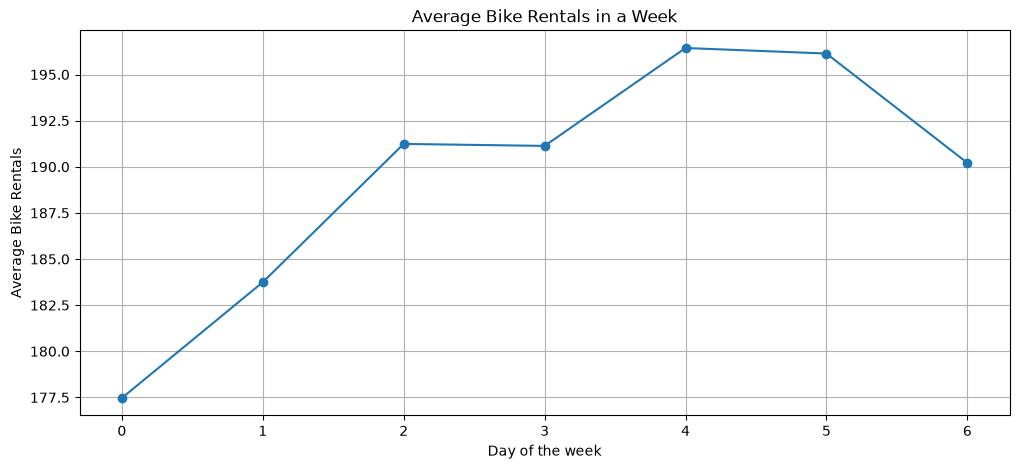

In [21]:
weekday_pattern = df.groupby(['weekday'])['cnt'].mean()

plt.figure(figsize=(12,5))

plt.plot(weekday_pattern, marker='o')
plt.xlabel('Day of the week')
plt.ylabel("Average Bike Rentals")
plt.title('Average Bike Rentals in a Week')
plt.grid(visible=True)

plt.show()

Look at the monthly behavior

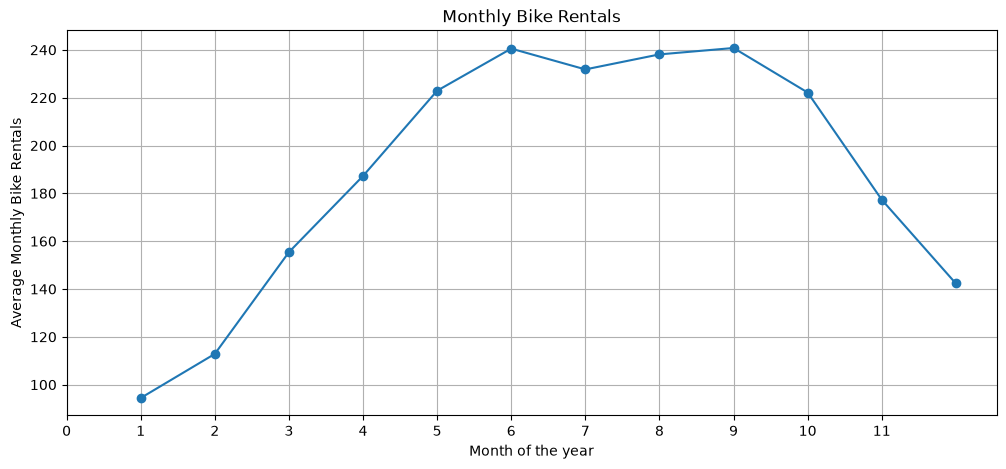

In [22]:
monthly = df.groupby('mnth')['cnt'].mean()

plt.figure(figsize=(12,5))
plt.plot(monthly, marker='o')
plt.xlabel('Month of the year')
plt.ylabel('Average Monthly Bike Rentals')
plt.title('Monthly Bike Rentals')

plt.grid(visible=True)
plt.xticks(range(12))
plt.show()

Test correlation and any missing time stamps

In [23]:
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    corr  =df['cnt'].autocorr(lag=lag)
    print(f'Autocorrelation at log: {lag} is {corr}')

Autocorrelation at log: 1 is 0.8438107986135388
Autocorrelation at log: 2 is 0.5941162004204696
Autocorrelation at log: 3 is 0.4043992190401478
Autocorrelation at log: 6 is 0.010244227099252334
Autocorrelation at log: 12 is -0.14027662725376705
Autocorrelation at log: 24 is 0.8157653661278814
Autocorrelation at log: 48 is 0.6783814540155295
Autocorrelation at log: 168 is 0.8211070666590071


In [24]:
time_diff = df["datetime"].diff()
missing_hours = time_diff[
    time_diff > pd.Timedelta(hours=1)].apply(
        lambda x: int(x.total_seconds()/3600) -1).sum()
    
missing_hours

np.int64(165)

# So, how much of the remaining variations is attributed to the remaining features?

In [25]:
df[["temp", "atemp", "hum", "windspeed", "cnt"]].corr()

,temp,atemp,hum,windspeed,cnt
temp,1.000000,0.987672,-0.069881,-0.023125,0.404772
atemp,0.987672,1.000000,-0.051918,-0.062336,0.400929
hum,-0.069881,-0.051918,1.000000,-0.290105,-0.322911
windspeed,-0.023125,-0.062336,-0.290105,1.000000,0.093234
cnt,0.404772,0.400929,-0.322911,0.093234,1.000000


### Observations and Conclusions ###

a) Observations.

1) Hourly Rental Plot.
Observations.
- The rental exhibits a long-term upward trend suggesting the series in non-stationary i it's mean. withing individual days, demand exhibits a recurring pattern. Demand's low in the early hours of the day, raising sharply around morning commute, falls around late morning/midday, rises again at arund 4 -6 pm then falls again in the evening and as the night progresses. This indicates a strong daily periodic component with a period of approximately 24 hours.

- The variability of rental counts appears to be increasing as the demand increases, suggesting possible heterscedasticity. This could be confirmed quantitively rather than drawing the conlusion from the plot alone.

2) Weekly Rental Plot.
observations.
- Average demand varies throughout the week, with highest average demand occuring towards the end of the week and lower at other points of the week. Average demand reaches approximately 196 rentals on Days 4–5 compared with approximately 177.5 rentals on Day 0.
- The relationship between the hour and rental demand differs substantially between working days and non - working days, suggestion an interaction between the time of the day and whether the day is a working day or not.
    
    Non-working days

    Demand tends to be lower during the morning, rises progressively toward the afternoon, reaches a       single broad peak, and then declines.

    Working days

    Demand exhibits two pronounced peaks, corresponding approximately to morning and evening commuting periods, with a decline between the two peaks.

- The variation across the week indicate a strong temporal strucuture with an approximate period of seven days.

3) Annual/Seasonal Plots and structures.
observations.
- It seems like the demand depends on the season of the year. Demand is substantially lower in colder months and increase during warmer months. This indicate that the demand could be influenced by weather patterns ans conditions. This could be investigated later for a quantitive evidence
- The monthly averages exhibit a strong annual seasonal pattern, with demand increasing from winter into summer and declining toward winter. Given the two-year observation period, this should be interpreted as evidence of annual seasonality rather than proof of a perfectly periodic yearly cycle.


b) Conclusion.

1) The dataset contains both smooth trends and strongly periodic structures. This makes it suitable for investigating whether polynomial, Fourier, and neural representations have different strengths when modeling real-world temporal demand.

2) Demand isn't determined purely by temporal structure as the as there is some correlation between the demand and weather factors such as temperature and humidity.

### Prepare the data 

In [26]:
df = df.sort_values('datetime').reset_index(drop=True)
df['timehours'] = (
    df['datetime'] - df['datetime'].min()
    
).dt.total_seconds() /3600

t_min = df['timehours'].min()
t_max = df['timehours'].max()

df['timenormalized'] = (
    2 * (df['timehours'] - t_min) / (t_max - t_min) - 1
)
df['timenormalized'].min(), df['timenormalized'].max()

(np.float64(-1.0), np.float64(1.0))

In [27]:
n = len(df)
train_end = 0.7
val_end = 0.85

train_len = int(n*train_end)
val_len = int(n*val_end)

train_set = df.iloc[:train_len].copy()
val_set = df.iloc[train_len:val_len].copy()
test_set = df.iloc[val_len:].copy()


In [28]:
print(f'Train target mean: {train_set['cnt'].mean()}')
print(f'Train target std: {train_set['cnt'].std()}\n')

print(f'Validation target mean: {val_set['cnt'].mean()}')
print(f'Validation target std: {val_set['cnt'].std()}\n')
print(f'Test target mean: {test_set['cnt'].mean()}')
print(f'Test target std: {test_set['cnt'].std()}')

Train target mean: 159.9336621454994
Train target std: 152.57946147468834

Validation target mean: 281.04142692750287
Validation target std: 223.27720891456858

Test target mean: 235.67740698120446
Test target std: 215.142437690706


This supports the conclusion that the data has an upward trend where the mean increases consisntently, demand is shifting with time.

Normalize the target

In [29]:
train_mean = train_set['cnt'].mean()
train_std = train_set['cnt'].std()

#* normalized train set
train_set['norm_cnt'] = (train_set['cnt'] - train_mean) / train_std
val_set['norm_cnt'] = (val_set['cnt'] - train_mean) / train_std
test_set['norm_cnt'] = (test_set['cnt'] - train_mean) / train_std

NOTE on the above cell:

we used train_mean and train_std to normalize the three sets. By doing this we make sure that there is no information leakage from the 'future' to influence the data and models later. This ensure that the models do not 'çheat' by learning infomtion from the future.

In [30]:
mean = df['cnt'].mean()
std = df['cnt'].std()
df['norm_cnt'] = (df['cnt'] - mean) / std

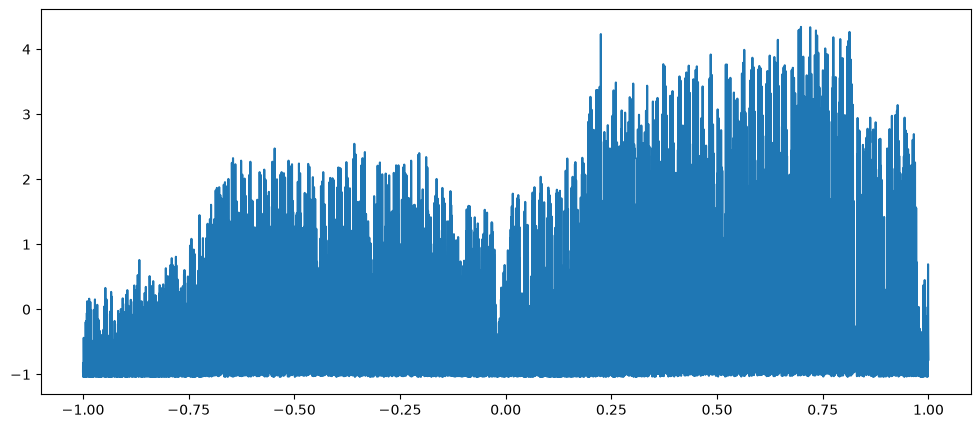

In [31]:
plt.figure(figsize=(12,5))

plt.plot(df['timenormalized'],df['norm_cnt'])

### Calculate the baseline metrics

In [68]:
from basisbench.evaluation.metrics import (
    mean_absolute_error,
    mean_square_error,
    root_mean_squared_error
)

In [44]:
train_mean = train_set['cnt'].mean()
train_std = train_set['cnt'].std()


baseline_mean_scaled = train_set['norm_cnt'].mean()
val_pred = np.full(len(val_set), baseline_mean_scaled) * train_std + train_mean
test_pred = np.full(len(test_set), baseline_mean_scaled) * train_std + train_mean
val_pred, test_pred

(array([159.93366215, 159.93366215, 159.93366215, ..., 159.93366215,
        159.93366215, 159.93366215], shape=(2607,)),
 array([159.93366215, 159.93366215, 159.93366215, ..., 159.93366215,
        159.93366215, 159.93366215], shape=(2607,)))

In [48]:
y_val = val_set['cnt'].to_numpy()
y_test = test_set['cnt'].to_numpy()

In [69]:
y_val = val_set["cnt"].to_numpy()
y_test = test_set["cnt"].to_numpy()

print("Validation")
print("MAE :", mean_absolute_error(y_val, val_pred))
print("RMSE:", root_mean_squared_error(y_val, val_pred))
print("MSE :", mean_square_error(y_val, val_pred))

print("\nTest")
print("MAE :", mean_absolute_error(y_test, test_pred))
print("RMSE:", root_mean_squared_error(y_test, test_pred))
print("MSE :", mean_square_error(y_test, test_pred))

Validation
MAE : 194.13512061097006
RMSE: 253.9698408771896
MSE : 64500.680075185

Test
MAE : 168.86681376186752
RMSE: 228.0474265742747
MSE : 52005.62876714921
